In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.backend import BackendPolicy, backend
from src.layers import Conv1D, Dense
from src.layers.activation import Flatten, ReLU, Softmax, Tanh,ELU, LeakyReLU
from src.loss.cross_entropy import CrossEntropy
from src.models.neural_network import Network
from src.models.sequential import Sequential
from src.optimizer.adam import Adam
from src.layers.activation.dropout import Dropout
from src.layers.global_concat_pool import GlobalConcatPool1D
from src.layers.masked_global_average import MaskedGlobalAveragePool1D


In [2]:
def prepare_har_dataset(csv_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, int, StandardScaler]:
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001]

    num_samples = features_raw.shape[0]
    num_channels = 6
    time_steps = 1500
    X = np.zeros((num_samples, time_steps, num_channels), dtype="float32")
    for i in range(num_channels):
        X[:, :, i] = features_raw[:, i*1500 : (i+1)*1500]
    mask = np.arange(time_steps) < lengths[:, None]
    # 2. Reconstruct the original 6 channels [Samples, Time, 6]
    X_6 = np.zeros((num_samples, time_steps, 6), dtype="float32")
    for i in range(6):
        X_6[:, :, i] = features_raw[:, i*time_steps : (i+1)*time_steps]
    acc_mag = np.linalg.norm(X_6[:, :, 0:3], axis=2, keepdims=True) 
    gyro_mag = np.linalg.norm(X_6[:, :, 3:6], axis=2, keepdims=True)
    X_8 = np.concatenate([X_6, acc_mag, gyro_mag], axis=2)
    scaler = StandardScaler()
    X_flat = X_8.reshape(-1, 8)
    X_scaled_flat = scaler.fit_transform(X_flat)
    X_final = X_scaled_flat.reshape(num_samples, time_steps, 8)
    mask = np.arange(time_steps) < lengths[:, None]
    X_final[~mask] = 0.0

    X_final = np.transpose(X_final, (0, 2, 1))

    return X_final, Y, lengths, X_final.nbytes + Y.nbytes, scaler


In [3]:
dataset_path = r"data\KU-HAR_v1.0_raw_samples.csv"
num_classes = 18
activity_map = {
    0: "Stand", 1: "Sit", 2: "Talk-sit", 3: "Talk-stand", 4: "Stand-sit",
    5: "Lay", 6: "Lay-stand", 7: "Pick", 8: "Jump", 9: "Push-up",
    10: "Sit-up", 11: "Walk", 12: "Walk-backward", 13: "Walk-circle",
    14: "Run", 15: "Stair-up", 16: "Stair-down", 17: "Table-tennis"
}


In [4]:

X,Y, lengths, total_bytes, scaler = prepare_har_dataset(dataset_path)
Y = np.eye(num_classes)[Y]

In [5]:
X_train, x_test, Y_train, Y_test, lengths_train, lengths_test = train_test_split(X, Y, lengths, test_size=0.2, random_state=2)


In [6]:
from src.layers.batch_normalization import BatchNormalization


backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=total_bytes)
learning_rate = 1e-03
optimizer = Adam(learning_rate=learning_rate)
loss_fn = CrossEntropy()
model = Sequential([
    Conv1D(filters=32, kernel_size=31, stride=3, padding=15, name="conv1"),
    BatchNormalization(),
    LeakyReLU(),
    Conv1D(filters=64, kernel_size=15, stride=2, padding=7, name="conv2"),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=7, stride=2, padding=3, name="conv3"),
    BatchNormalization(),
    ELU(),
    GlobalConcatPool1D(name="masked_gap"),
    Dense(128),
    BatchNormalization(),
    ELU(),
    Dropout(0.5),
    Dense(18),
    Softmax()
])

model.scaler = scaler
model.compile(optimizer=optimizer, loss=loss_fn)
history, total_time = model.fit(X_train, Y_train, epochs=80, batch_size=128, verbose=5, mask=lengths_train, lr_decay_epochs=20, lr_decay=0.5)
model.save(r"models\har_model_hybrid_v1.nnp")

2026-03-22 00:31:10,807 | INFO | src.backend | GPU requested. Dataset size: 440916740 bytes. Minimum for GPU: 8000000 bytes.
2026-03-22 00:31:11,370 | INFO | src.backend | CuPy available: True.
2026-03-22 00:31:11,370 | INFO | src.backend | Using backend: cupy
Epoch 1/80 - Loss: 1.901842 - 17.49s/epoch - ETA: 00:23:01
Epoch 6/80 - Loss: 0.524474 - 16.45s/epoch - ETA: 00:19:48
Epoch 11/80 - Loss: 0.378992 - 14.18s/epoch - ETA: 00:18:05
Epoch 16/80 - Loss: 0.313715 - 14.15s/epoch - ETA: 00:16:16
Epoch 20: Learning rate decayed to 0.000500
Epoch 21/80 - Loss: 0.254874 - 13.95s/epoch - ETA: 00:14:43
Epoch 26/80 - Loss: 0.225091 - 13.78s/epoch - ETA: 00:13:17
Epoch 31/80 - Loss: 0.208806 - 13.09s/epoch - ETA: 00:11:51
Epoch 36/80 - Loss: 0.204202 - 13.04s/epoch - ETA: 00:10:29
Epoch 40: Learning rate decayed to 0.000250
Epoch 41/80 - Loss: 0.175178 - 13.00s/epoch - ETA: 00:09:11
Epoch 46/80 - Loss: 0.168236 - 11.22s/epoch - ETA: 00:07:50
Epoch 51/80 - Loss: 0.161016 - 11.04s/epoch - ETA: 00

In [ ]:
_loaded = Network.load(r"models\har_model_hybrid_v1.nnp")
print(_loaded.scaler)

StandardScaler()


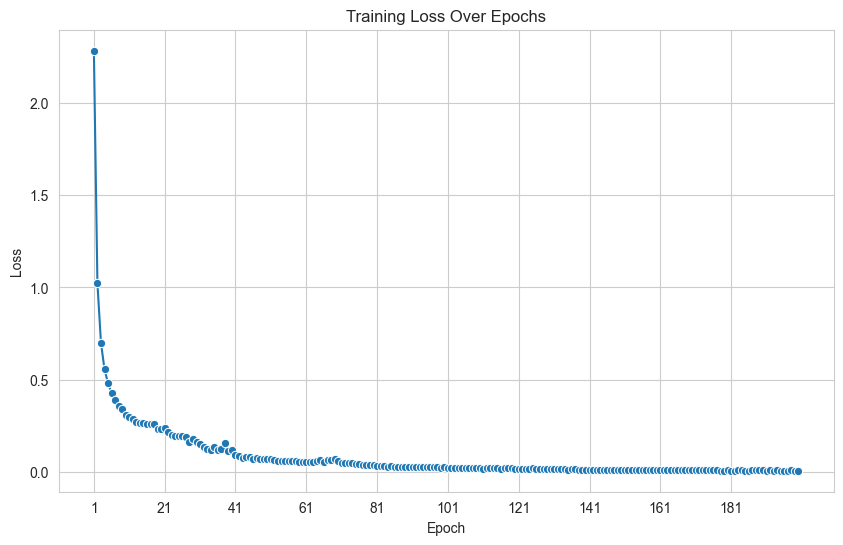

In [10]:
def plot_training_history(history, title="Training Loss Over Epochs"):
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(1, len(history) + 1), y=history, marker="o")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(history) + 1, max(1, len(history) // 10)))
    plt.show()

plot_training_history(history)

In [ ]:
def plot_confusion_matrix(x_test, y_test, model, lengths_test, activity_map):
    predictions = model.predict(x_test, mask=lengths_test)
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=[activity_map[i] for i in range(num_classes)]))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[activity_map[i] for i in range(num_classes)], yticklabels=[activity_map[i] for i in range(num_classes)])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

Test Accuracy: 0.9390
Test F1 Score: 0.9392
Classification Report:
               precision    recall  f1-score   support

        Stand       0.70      0.76      0.73       117
          Sit       0.69      0.78      0.73       101
     Talk-sit       0.92      0.93      0.93       132
   Talk-stand       1.00      0.99      1.00       112
    Stand-sit       1.00      1.00      1.00       183
          Lay       0.84      0.67      0.74       115
    Lay-stand       1.00      1.00      1.00       108
         Pick       0.99      1.00      1.00       108
         Jump       1.00      0.97      0.98        99
      Push-up       1.00      0.99      1.00       105
       Sit-up       1.00      1.00      1.00        89
         Walk       0.98      0.97      0.98       109
Walk-backward       0.94      1.00      0.97        46
  Walk-circle       0.97      0.91      0.94        35
          Run       0.99      0.97      0.98       117
     Stair-up       0.97      1.00      0.98        

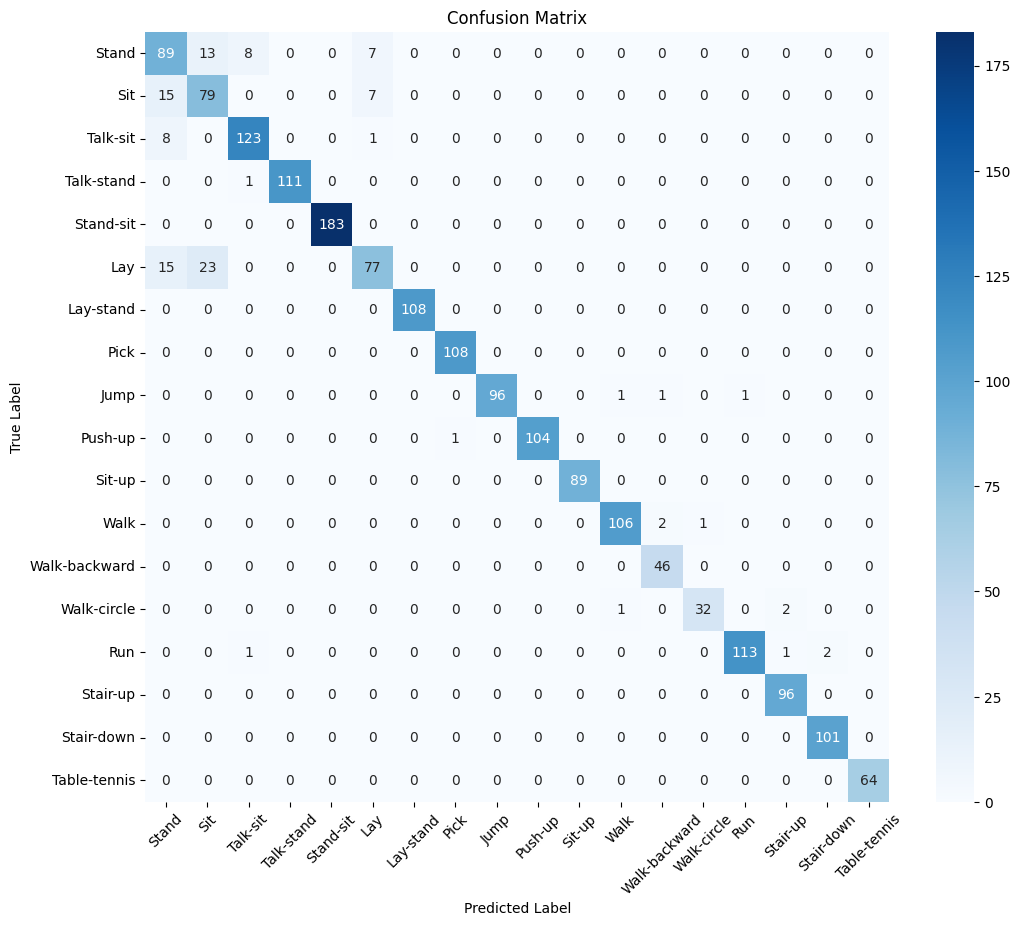

In [ ]:
plot_confusion_matrix(x_test, Y_test, _loaded, lengths_test=lengths_test, activity_map=activity_map)

In [15]:

def compare_gpu_vs_cpu(X, Y, model: Network, epochs=1, batch_size=64, verbose=5):
    if not backend._cupy_runtime_ok:
        print("GPU runtime not available. Skipping GPU vs CPU comparison.")
        return -1,-1
    backend.configure(policy=BackendPolicy(use_gpu=False), dataset_bytes=0)
    model.reset()
    X_cpu, Y_cpu = backend.asarray(X), backend.asarray(Y)
    _, cpu_time = model.fit(X_cpu, Y_cpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    model.reset()
    backend.configure(policy=BackendPolicy(use_gpu=True, min_gpu_bytes=0), dataset_bytes=10)
    X_gpu, Y_gpu = backend.asarray(X), backend.asarray(Y)
    _, gpu_time = model.fit(X_gpu, Y_gpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return cpu_time, gpu_time

cpu_time, gpu_time = compare_gpu_vs_cpu(X, Y, model, epochs=25, batch_size=1024, verbose=5)
print(f"CPU time: {cpu_time:.2f} seconds")
print(f"GPU time: {gpu_time:.2f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")



2026-03-21 21:56:52,311 | INFO | src.backend | Using backend: numpy


KeyboardInterrupt: 

In [ ]:
def prepare_har_dataset_magnitude(csv_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001]

    num_samples = features_raw.shape[0]
    num_channels = 6
    time_steps = 1500
    X = np.zeros((num_samples, time_steps, num_channels), dtype="float32")
    for i in range(num_channels):
        X[:, :, i] = features_raw[:, i*1500 : (i+1)*1500]
    acc_mag = np.sqrt(np.sum(X[:, :, 0:3]**2, axis=-1, keepdims=True))
    gyro_mag = np.sqrt(np.sum(X[:, :, 3:6]**2, axis=-1, keepdims=True))
    
    X_mag = np.concatenate((acc_mag, gyro_mag), axis=-1)
    
    mask = np.arange(time_steps) < lengths[:, None]
    X_mag[~mask] = 0.0
    X_final = np.transpose(X_mag, (0, 2, 1))
    return X_final, Y, lengths, X_final.nbytes + Y.nbytes

print("Preparing Magnitude Dataset...")
X_mag, _, lengths, total_bytes_mag = prepare_har_dataset_magnitude(dataset_path)

X_train_m, X_test_m, Y_train_m, Y_test_m, lengths_train_m, lengths_test_m = train_test_split(
    X_mag, Y, lengths, test_size=0.2, random_state=42
)


Preparing Magnitude Dataset...
Building Magnitude Model (2 Channels)...
2026-03-21 20:27:29,227 | INFO | src.backend | GPU requested. Dataset size: 110256740 bytes. Minimum for GPU: 8000000 bytes.
2026-03-21 20:27:29,655 | INFO | src.backend | CuPy available: True.
2026-03-21 20:27:29,656 | INFO | src.backend | Using backend: cupy


NameError: name 'GlobalConcatPool1D' is not defined

In [ ]:

print("Building Magnitude Model (2 Channels)...")
backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=total_bytes_mag)
model_mag = Sequential([
    # Same updated logic for the magnitude model
    Conv1D(filters=32, kernel_size=31, stride=3, padding=15, name="m_conv1"),
    BatchNormalization(),
    LeakyReLU(),
    Conv1D(filters=64, kernel_size=15, stride=2, padding=7, name="m_conv2"),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=7, stride=2, padding=3, name="m_conv3"),
    BatchNormalization(),
    ELU(),
    GlobalConcatPool1D(name="m_gap"),
    Dense(128),
    BatchNormalization(),
    ELU(),
    Dropout(0.5),
    Dense(18),
    Softmax()
])

model_mag.compile(optimizer=Adam(learning_rate=1e-03), loss=CrossEntropy())
history_mag, _ = model_mag.fit(X_train_m, Y_train_m, epochs=80, batch_size=1024, verbose=5, mask=lengths_train_m, lr_decay_epochs=20, lr_decay=0.7)


model_mag.save('har_model_magnitude_v1.nnp')
print("Model saved to har_model_magnitude_v1.nnp")

Building Magnitude Model (2 Channels)...
2026-03-21 20:27:55,470 | INFO | src.backend | GPU requested. Dataset size: 110256740 bytes. Minimum for GPU: 8000000 bytes.
2026-03-21 20:27:55,471 | INFO | src.backend | CuPy available: True.
2026-03-21 20:27:55,472 | INFO | src.backend | Using backend: cupy
Epoch 1/250 - Loss: 8.361465 - 4.51s/epoch - ETA: 00:18:43
Epoch 6/250 - Loss: 2.328162 - 3.79s/epoch - ETA: 00:15:54
Epoch 11/250 - Loss: 1.645886 - 3.79s/epoch - ETA: 00:15:21
Epoch 16/250 - Loss: 1.301209 - 3.81s/epoch - ETA: 00:14:58
Epoch 21/250 - Loss: 1.095711 - 3.81s/epoch - ETA: 00:14:37
Epoch 26/250 - Loss: 0.929805 - 3.83s/epoch - ETA: 00:14:18
Epoch 31/250 - Loss: 0.803165 - 3.79s/epoch - ETA: 00:13:59
Epoch 36/250 - Loss: 0.742859 - 3.73s/epoch - ETA: 00:13:37
Epoch 41/250 - Loss: 0.644330 - 3.66s/epoch - ETA: 00:13:19
Epoch 46/250 - Loss: 0.571685 - 3.69s/epoch - ETA: 00:12:57
Epoch 50: Learning rate decayed to 0.000700
Epoch 51/250 - Loss: 0.541529 - 3.68s/epoch - ETA: 00:12

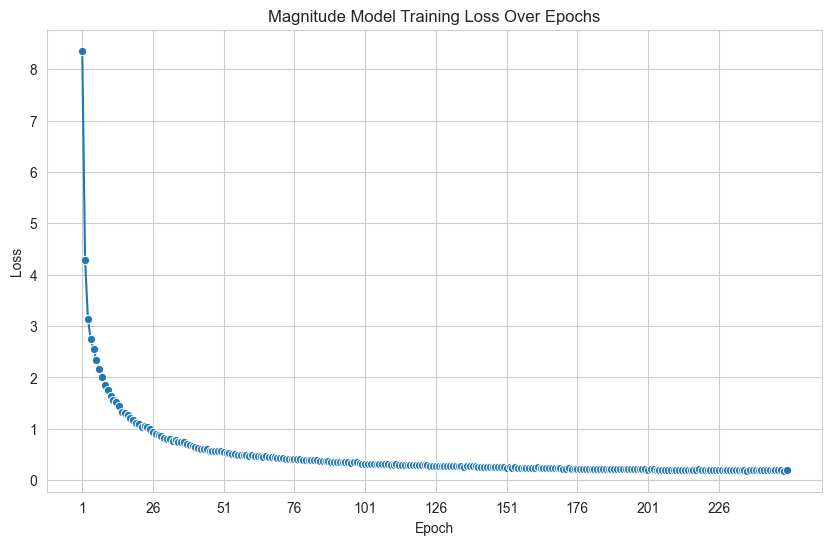

Test Accuracy: 0.8830
Test F1 Score: 0.8831
Classification Report:
               precision    recall  f1-score   support

        Stand       0.59      0.71      0.64       109
          Sit       0.72      0.65      0.68       128
     Talk-sit       0.88      0.90      0.89        96
   Talk-stand       0.95      0.96      0.96       113
    Stand-sit       0.96      0.96      0.96       142
          Lay       0.91      0.81      0.86       128
    Lay-stand       0.90      0.94      0.92       128
         Pick       0.93      0.97      0.95       143
         Jump       0.97      1.00      0.99       101
      Push-up       0.97      0.96      0.97       108
       Sit-up       0.93      0.88      0.90        80
         Walk       0.84      0.91      0.88       112
Walk-backward       0.81      0.76      0.78        45
  Walk-circle       0.97      0.79      0.87        39
          Run       0.94      0.99      0.96        95
     Stair-up       0.88      0.85      0.87       1

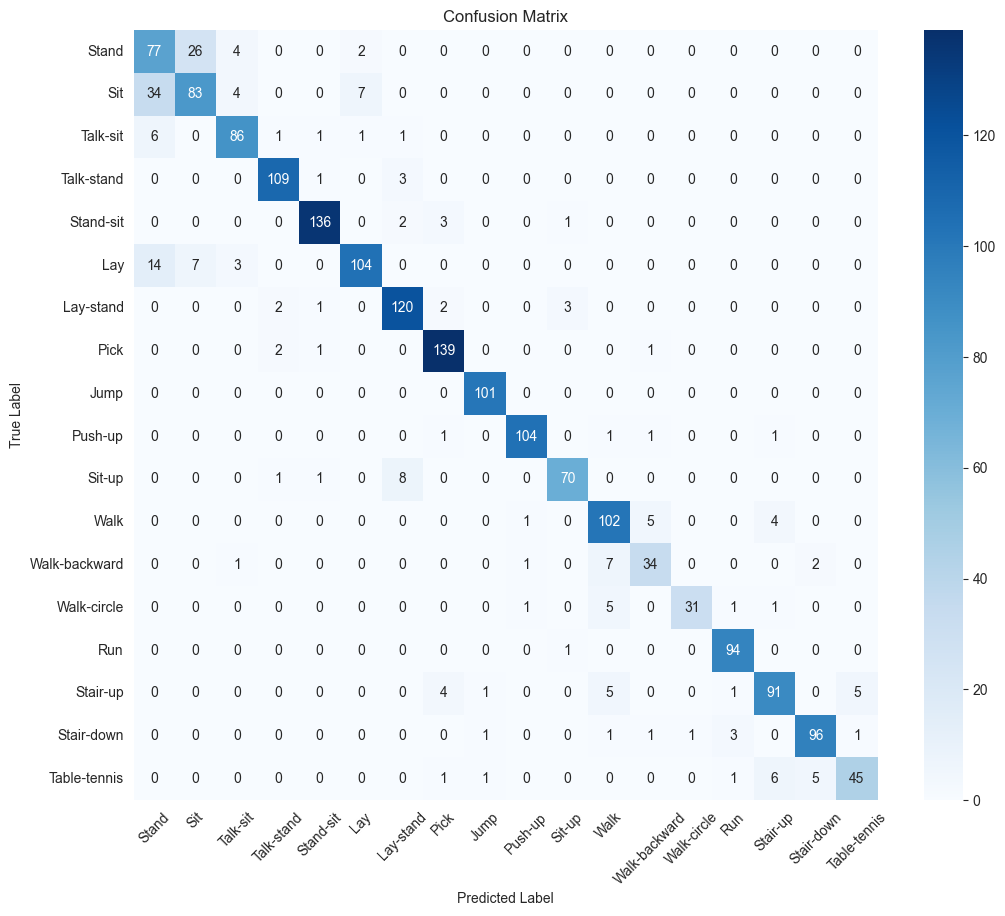

In [18]:
plot_training_history(history_mag, title="Magnitude Model Training Loss Over Epochs")
plot_confusion_matrix(X_test_m, Y_test_m, model_mag, lengths_test_m, activity_map)